# ID Graph — Connected Components & Type Connectivity Analysis

In [1]:
import duckdb
import numpy as np
import pandas as pd
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components

pd.set_option("display.width", 140)

# --- config ---
SAMPLE = True  # flip to False for the full 200-file run (takes much longer; watch disk)
DATA_DIR = "/Users/ravirajan/code/data/ID"
PARQUET_GLOB = (
    f"{DATA_DIR}/id5_tapad_li_joined_outer/part-0000[0-9]-*.parquet"  # 10/200 files (~5%)
    if SAMPLE
    else f"{DATA_DIR}/id5_tapad_li_joined_outer/*.parquet"
)
SUFFIX = "_sample" if SAMPLE else ""
NODES_CACHE = f"{DATA_DIR}/id5_component_map{SUFFIX}.parquet"
EDGES_CACHE = f"{DATA_DIR}/id5_edges{SUFFIX}.parquet"
RESULT_CACHE = f"{DATA_DIR}/id5_cc_result{SUFFIX}.parquet"  # node_id, type, component, component_size (unfiltered CC)
VIA_KEYS_CACHE = f"{DATA_DIR}/id5_via_keys{SUFFIX}.parquet"  # node_id, via_type, via_key -- the raw grouping-key values

FILTER_TYPES = [
    "HARDWARE_IDFA",
    "HARDWARE_ANDROID_AD_ID",
    "HEM_MD5",
    "ID5_UID",
    "TTD",
    "ST",
]

# high-confidence filter thresholds (used in the Filters section below)
N1_VIA_TYPE_COUNT = 2   # link corroborated across >=N1 independent grouping-key types (id5/tapad/liid)
N2_WEIGHT = 2            # link seen via >=N2 distinct grouping-key values total


## Build: nodes + weighted edges (DuckDB)

Nodes = `(type, value)` identifiers. Edges = two nodes co-occurring on rows sharing the same `liid` / `individual_id5` / `individual_id_tapad`. Each edge carries:
- `weight` — number of distinct grouping keys that produced the link (more repetition = more evidence, but see the Findings section — high weight isn't always trustworthy on its own)
- `via_type_count` — number of *independent* grouping-key **types** (id5 vs tapad vs liid) that corroborate the link — this turned out to be the better confidence signal.

Only grouping keys that tie together >1 distinct node are ever processed (most id5/tapad/liid values are singletons in this type set) — this is what keeps the DuckDB query from blowing up memory/disk on the full 1.2B-row scan (an earlier window-function version didn't do this and filled the disk).

Results are cached to parquet so re-running this notebook doesn't redo the expensive scan.

In [2]:
import os

def pairs_via(key_col: str, via_label: str) -> str:
    return f"""
    {via_label}_multi AS (
        SELECT {key_col}
        FROM base
        WHERE {key_col} IS NOT NULL
        GROUP BY {key_col}
        HAVING COUNT(DISTINCT node_id) > 1
    ),
    {via_label}_base AS (
        SELECT b.node_id, b.{key_col}
        FROM base b
        JOIN {via_label}_multi USING ({key_col})
    ),
    {via_label}_pairs AS (
        SELECT a.node_id AS node_a, b.node_id AS node_b,
               '{via_label}' AS via_type, a.{key_col} AS via_key
        FROM {via_label}_base a
        JOIN {via_label}_base b
          ON a.{key_col} = b.{key_col} AND a.node_id < b.node_id
    )
    """

if os.path.exists(NODES_CACHE) and os.path.exists(EDGES_CACHE):
    print(f"Loading cached node/edge parquet for SAMPLE={SAMPLE} ...")
    node_types = pd.read_parquet(NODES_CACHE, columns=["node_id", "type"]).drop_duplicates()
    edges_df = pd.read_parquet(EDGES_CACHE)
else:
    print(f"No cache found -- building via DuckDB (SAMPLE={SAMPLE}) ...")
    con = duckdb.connect()
    con.execute("SET preserve_insertion_order=false")
    con.execute("SET max_temp_directory_size='100GiB'")  # fail fast instead of filling the disk
    type_list = ", ".join(f"'{t}'" for t in FILTER_TYPES)

    BASE_SQL = f"""
        SELECT type || ':' || value AS node_id, type,
               individual_id5, individual_id_tapad, liid
        FROM read_parquet('{PARQUET_GLOB}')
        WHERE type IN ({type_list}) AND value IS NOT NULL
    """

    FULL_SQL = f"""
    WITH base AS ({BASE_SQL}),
    {pairs_via("individual_id5", "id5")},
    {pairs_via("individual_id_tapad", "tapad")},
    {pairs_via("liid", "liid")},
    all_pairs AS (
        SELECT * FROM id5_pairs
        UNION ALL
        SELECT * FROM tapad_pairs
        UNION ALL
        SELECT * FROM liid_pairs
    )
    SELECT node_a, node_b,
           COUNT(*) AS weight,
           COUNT(DISTINCT via_type) AS via_type_count
    FROM all_pairs
    GROUP BY node_a, node_b
    """

    NODE_TYPES_SQL = f"WITH base AS ({BASE_SQL}) SELECT DISTINCT node_id, type FROM base"

    node_types = con.execute(NODE_TYPES_SQL).df()
    edges_df = con.execute(FULL_SQL).df()

    node_types.to_parquet(NODES_CACHE)
    edges_df.to_parquet(EDGES_CACHE)
    print(f"Wrote {NODES_CACHE} and {EDGES_CACHE}")

print(f"{len(node_types):,} nodes, {len(edges_df):,} edges")
node_types["type"].value_counts()

Loading cached node/edge parquet for SAMPLE=True ...


59,548,330 nodes, 8,520,747 edges


type
ID5_UID                   52388963
TTD                        6656899
HARDWARE_IDFA               209766
HARDWARE_ANDROID_AD_ID      205861
HEM_MD5                      49528
ST                           37313
Name: count, dtype: int64

## Connected components

`connected_components` computes the full transitive closure over the edge graph — two nodes end up in the same component if there's *any* path between them, regardless of hop count. This is what already answers "is ST linked to HEM_MD5 via a shared TTD" without any special multi-hop code — see the Findings section for the important caveat about this.

### Why build edges at all? (the raw data only gives us groups)

The raw data only tells us **group membership**: "these `k` nodes co-occurred under this key" — exactly what `via_keys` is (one row per `(node_id, via_type, via_key)`). That's not a graph yet. Two things need actual pairwise edges, not membership lists:
- `connected_components` traverses edges to find *transitive* links — two nodes that never directly co-occur anywhere can still land in the same identity if a chain of edges connects them. A membership list alone has no notion of "chain."
- `weight`/`via_type_count` are properties of a *specific pair*, not of a node or a group — there's no such thing as "an edge's weight" until you've decided what the edge *is*. This is exactly the signal that separated the `tapad` fraud pattern (Finding #2/#4) from ordinary linkage: both are pairwise properties, impossible to compute from membership alone.

**Worked example.** Say `liid="abc123"` ties together 3 nodes:
```
node_id            via_type  via_key
ID5_UID:A          liid      abc123
TTD:B              liid      abc123
HARDWARE_IDFA:C    liid      abc123
```
The self-join (in the DuckDB build cell above / `pairs_via()` in the Databricks build) produces the full k×k cross product (9 rows for k=3) — every node paired with every node in the group, including itself, and each distinct pair appearing twice (`(A,B)` and `(B,A)`). The `node_a < node_b` filter drops both problems at once: self-pairs never satisfy `A < A`, and of the two mirrored rows for any distinct pair, exactly one satisfies the strict inequality. What survives (lexicographically `HARDWARE_IDFA:C` < `ID5_UID:A` < `TTD:B`, so 3 pairs = `C(3,2)`):
```
node_a               node_b       via_type  via_key
HARDWARE_IDFA:C       ID5_UID:A    liid      abc123
HARDWARE_IDFA:C       TTD:B        liid      abc123
ID5_UID:A             TTD:B        liid      abc123
```
Group membership just became actual edges. Now suppose `(ID5_UID:A, TTD:B)` *also* co-occurs under a different `liid` and under an `id5` key elsewhere, while `HARDWARE_IDFA:C`'s two edges are *only* ever seen through this one group. After the final `GROUP BY node_a, node_b`:
```
node_a               node_b       weight  via_type_count
HARDWARE_IDFA:C       ID5_UID:A    1       1
HARDWARE_IDFA:C       TTD:B        1       1
ID5_UID:A             TTD:B        3       2   <- seen 3x, via 2 different source types
```
And even though `HARDWARE_IDFA:C` and `TTD:B` never co-occur anywhere except through this one group, `connected_components` still puts all three in the same identity: `C↔A` and `A↔B` implies `C` and `B` are transitively linked — exactly what a membership list alone can't express.

In [3]:
import os

# Build the vertex index ONCE and reuse it across every CC run (unfiltered + all the
# filtered comparisons below). Rebuilding a ~60M-entry dict per call, and computing
# component sizes via a pandas groupby+join with ~as many groups as rows, was the
# actual bottleneck last run (~20 min) -- np.bincount is vectorized and does the same
# job in a fraction of the time.
NODE_INDEX = {n: i for i, n in enumerate(node_types["node_id"].to_numpy())}
N_NODES = len(NODE_INDEX)


def run_cc(edges_df, return_full=False, node_types_df=None):
    """Run connected_components for a given edge set against the fixed NODE_INDEX.
    return_full=False -> (sizes_by_label, n_components) as plain numpy, for cheap
    summary stats (used by the filter comparison below).
    return_full=True  -> (node_types_df with component/component_size columns, n_components)."""
    row = edges_df["node_a"].map(NODE_INDEX).to_numpy()
    col = edges_df["node_b"].map(NODE_INDEX).to_numpy()
    data = np.ones(len(row), dtype=np.int8)
    graph = coo_matrix((data, (row, col)), shape=(N_NODES, N_NODES))

    n_components, labels = connected_components(graph, directed=False)
    sizes = np.bincount(labels, minlength=n_components)

    if not return_full:
        return sizes, n_components

    result = node_types_df.copy()
    result["component"] = labels
    result["component_size"] = sizes[labels]
    return result, n_components


if os.path.exists(RESULT_CACHE):
    print(f"Loading cached CC result for SAMPLE={SAMPLE} ...")
    result = pd.read_parquet(RESULT_CACHE)
    n_components = result["component"].nunique()
else:
    print("No cache found -- running connected_components ...")
    result, n_components = run_cc(edges_df, return_full=True, node_types_df=node_types)
    result.to_parquet(RESULT_CACHE)
    print(f"Wrote {RESULT_CACHE}")

print(f"{n_components:,} components over {len(result):,} nodes")

Loading cached CC result for SAMPLE=True ...


52,393,107 components over 59,548,330 nodes


In [ ]:
## Per-type connectivity + identities (singleton = never linked to anything)
connected = result[result["component_size"] > 1]

summary = (
    result.assign(is_singleton=result["component_size"] == 1)
    .groupby("type")
    .agg(total_nodes=("node_id", "count"), singleton_nodes=("is_singleton", "sum"))
)
summary["connected_nodes"] = summary["total_nodes"] - summary["singleton_nodes"]
summary["pct_connected"] = (100 * summary["connected_nodes"] / summary["total_nodes"]).round(2)

# Identities: how many DISTINCT components (= merged identities) do a type's connected
# nodes actually resolve to? E.g. ST has 27,595 connected nodes, but if several ST
# values land in the same component (same person/device), that's fewer real identities
# than raw connected-node count -- nodes_per_identity > 1 means real consolidation.
n_identities_by_type = connected.groupby("type")["component"].nunique().rename("n_identities")
summary = summary.join(n_identities_by_type)
summary["nodes_per_identity"] = (summary["connected_nodes"] / summary["n_identities"]).round(2)
# reduction: (connected_nodes - n_identities) is the count of nodes that got merged
# INTO an existing identity rather than forming their own -- the actual shrinkage from
# raw node count down to distinct identities. Same numerator for both, two denominators:
# reduction_pct   = shrinkage as a % of just the connected subset (higher = more
#                   consolidation among nodes that link to something).
# reduction_all_pct = same shrinkage as a % of the WHOLE type population -- diluted by
#                   untouched singletons, which contribute zero reduction but still
#                   count in the denominator.
_merged_away = summary["connected_nodes"] - summary["n_identities"]
summary["reduction_pct"] = (100 * _merged_away / summary["connected_nodes"]).round(2)
summary["reduction_all_pct"] = (100 * _merged_away / summary["total_nodes"]).round(2)

# Average degree: mean number of direct edges per CONNECTED node of this type. Computed
# independently here (not reused from the later Type x type matrix cell) so this cell
# stays self-contained regardless of execution order.
_type_map = node_types.set_index("node_id")["type"]
_deg_counts = pd.concat([edges_df["node_a"].map(_type_map), edges_df["node_b"].map(_type_map)]).value_counts()
summary["avg_deg_conn"] = (_deg_counts / summary["connected_nodes"]).round(2)

# shorter column names -- the full names wrapped the table past terminal width
summary = summary.rename(columns={
    "total_nodes": "total",
    "singleton_nodes": "singleton",
    "connected_nodes": "connected",
    "pct_connected": "pct_conn",
    "n_identities": "conn_identities",
    "nodes_per_identity": "nodes/id",
    "reduction_pct": "reduce_conn",
    "reduction_all_pct": "reduce_all",
})
print(summary.to_string())

n_total_identities = result["component"].nunique()
n_nonsingleton_identities = connected["component"].nunique()
print(f"\nTotal identities (components): {n_total_identities:,}")
print(f"  non-singleton (real merges of >=2 nodes): {n_nonsingleton_identities:,}")
print(f"  singleton (isolated, single-node): {n_total_identities - n_nonsingleton_identities:,}")

print("\nLargest components:")
print(
    result[["component", "component_size"]]
    .drop_duplicates("component")
    .nlargest(10, "component_size")
    .set_index("component")["component_size"]
    .to_string()
)

                           total  singleton  connected  pct_conn  conn_identities  nodes/id  reduce_conn  reduce_all  avg_deg_conn
type                                                                                                                              
HARDWARE_ANDROID_AD_ID    205861      49368     156493     76.02            88871      1.76        43.21       32.85          2.51
HARDWARE_IDFA             209766      55662     154104     73.46            89570      1.72        41.88       30.76          2.32
HEM_MD5                    49528      24699      24829     50.13            22369      1.11         9.91        4.97          1.90
ID5_UID                 52388963   41565663   10823300     20.66          5765333      1.88        46.73        9.65          1.23
ST                         37313       9718      27595     73.96            19797      1.39        28.26       20.90          2.73
TTD                      6656899    4625635    2031264     30.51          1692152  

## Identity (component) distributions -- all identities, singletons included

Three cuts over every identity in the graph (not just the connected subset):
1. **Size distribution** -- how many identities have 1 node, 2 nodes, 3 nodes, etc.
2. **`n_type`** -- how many *distinct node types* are inside an identity (1..6). A singleton trivially has n_type=1.
3. **`n_via_type`** -- how many *distinct grouping-key types* (id5/tapad/liid) produced an identity's internal edges. A singleton has n_via_type=0 (no internal edges at all); this is a different axis than `via_type_count` on an individual edge -- this is the union across every edge inside the whole identity.

Then the joint `n_type x n_via_type` distribution. Caveat: `n_type=1` mixes two very different populations -- the 46.3M trivial singletons, and the small number of real multi-node same-type clusters (e.g. Finding #4's 70-node all-`HARDWARE_ANDROID_AD_ID` clique). The row-normalized view below separates them via the `n_via_type=0` column (singletons only).

In [ ]:
# Part 1: identity size distribution
component_sizes = result.drop_duplicates("component")["component_size"]
size_dist = component_sizes.value_counts().sort_index()
size_dist_pct = (100 * size_dist / len(component_sizes)).round(4)
print("=== Identity size distribution (all identities, singletons included) ===")
print(pd.DataFrame({"n_identities": size_dist, "pct": size_dist_pct}).to_string())

# Part 2a: distribution by n_type
n_type_per_component = result.groupby("component")["type"].nunique()
n_type_dist = n_type_per_component.value_counts().sort_index()
n_type_dist_pct = (100 * n_type_dist / len(n_type_per_component)).round(4)
print("\n=== Distribution by n_type (distinct node types per identity) ===")
print(pd.DataFrame({"n_identities": n_type_dist, "pct": n_type_dist_pct}).to_string())

# Part 2b: distribution by n_via_type
via_keys_with_component = via_keys.merge(result[["node_id", "component"]], on="node_id", how="left")
n_via_type_per_component = via_keys_with_component.groupby("component")["via_type"].nunique()
n_via_type_per_component = n_via_type_per_component.reindex(n_type_per_component.index, fill_value=0)
n_via_dist = n_via_type_per_component.value_counts().sort_index()
n_via_dist_pct = (100 * n_via_dist / len(n_via_type_per_component)).round(4)
print("\n=== Distribution by n_via_type (distinct grouping-key types per identity; 0 = singleton) ===")
print(pd.DataFrame({"n_identities": n_via_dist, "pct": n_via_dist_pct}).to_string())

=== Identity size distribution (all identities, singletons included) ===
                n_identities      pct
component_size                       
1                   46330745  88.4291
2                    5182996   9.8925
3                     718357   1.3711
4                     125092   0.2388
5                      26026   0.0497
6                       6454   0.0123
7                       1963   0.0037
8                        747   0.0014
9                        346   0.0007
10                       155   0.0003
11                       102   0.0002
12                        50   0.0001
13                        34   0.0001
14                        14   0.0000
15                         8   0.0000
16                         4   0.0000
17                         2   0.0000
19                         3   0.0000
20                         1   0.0000
23                         1   0.0000
24                         1   0.0000
25                         1   0.0000
27             

In [ ]:
# Part 3: joint n_type x n_via_type distribution
combo = pd.DataFrame({"n_type": n_type_per_component, "n_via_type": n_via_type_per_component})
combo_counts = combo.groupby(["n_type", "n_via_type"]).size().unstack("n_via_type", fill_value=0)
combo_pct = (100 * combo_counts.div(combo_counts.sum(axis=1), axis=0)).round(2)

print("n_type x n_via_type -- counts:")
print(combo_counts.to_string())
print("\nn_type x n_via_type -- row-normalized %:")
print(combo_pct.to_string())

=== n_type x n_via_type -- counts ===
n_via_type         0        1     2  3
n_type                                
1           46330745  4462792   359  0
2                  0  1582786  1240  0
3                  0    13255   659  1
4                  0     1048   160  0
5                  0       43    17  0
6                  0        2     0  0

=== n_type x n_via_type -- row-normalized % ===
n_via_type      0       1      2     3
n_type                                
1           91.21    8.79   0.00  0.00
2            0.00   99.92   0.08  0.00
3            0.00   95.26   4.74  0.01
4            0.00   86.75  13.25  0.00
5            0.00   71.67  28.33  0.00
6            0.00  100.00   0.00  0.00


## Browse a component

Two ways to inspect the actual contents of a component (identity cluster): look up one by `component` id, or list the top-N largest with their members. `view_component` also pulls the edges *within* that component from `edges_df`, so you can see exactly which links produced the merge (and their weight/via_type_count — worth checking before trusting a large component, per Findings).

In [1]:
def view_component(component_id):
    """Members of one component, plus the edges among them (with weight/via_type_count)."""
    members = result[result["component"] == component_id][["node_id", "type"]].reset_index(drop=True)
    member_ids = set(members["node_id"])
    edges_in = edges_df[
        edges_df["node_a"].isin(member_ids) & edges_df["node_b"].isin(member_ids)
    ][["node_a", "node_b", "weight", "via_type_count"]]
    print(f"Component {component_id}: {len(members)} nodes, {len(edges_in)} internal edges")
    return members, edges_in


def largest_components(n=5):
    """Top-n largest components with their full member list."""
    top_ids = (
        result[["component", "component_size"]]
        .drop_duplicates("component")
        .nlargest(n, "component_size")["component"]
    )
    for cid in top_ids:
        members, edges_in = view_component(cid)
        print(members.to_string(index=False))
        print(edges_in.to_string(index=False))
        print()


# example: the single largest component in the sample
#members, edges_in = view_component(result[["component", "component_size"]].drop_duplicates("component").nlargest(1, "component_size")["component"].iloc[0])
#print(members.to_string(index=False))
#print("\nInternal edges:")
#print(edges_in.to_string(index=False))

In [6]:
# Fan-out audit: for each grouping key (id5/tapad/liid), how many distinct nodes does it
# tie together? A handful of extreme outliers here (like the tapad id above, fanning out
# to 70 AAIDs) are exactly what produces suspiciously large/complete-clique components.
# Uses the same disk-safety settings as the build cell (this query type is what filled the
# disk earlier in this session when run without them).
con = duckdb.connect()
con.execute("SET preserve_insertion_order=false")
con.execute("SET max_temp_directory_size='100GiB'")
type_list = ", ".join(f"'{t}'" for t in FILTER_TYPES)

FANOUT_SQL = f"""
WITH base AS (
    SELECT type || ':' || value AS node_id, individual_id5, individual_id_tapad, liid
    FROM read_parquet('{PARQUET_GLOB}')
    WHERE type IN ({type_list}) AND value IS NOT NULL
)
SELECT 'id5' AS via, individual_id5 AS key, COUNT(DISTINCT node_id) AS n_distinct_nodes
FROM base WHERE individual_id5 IS NOT NULL GROUP BY individual_id5
UNION ALL
SELECT 'tapad', individual_id_tapad, COUNT(DISTINCT node_id)
FROM base WHERE individual_id_tapad IS NOT NULL GROUP BY individual_id_tapad
UNION ALL
SELECT 'liid', liid, COUNT(DISTINCT node_id)
FROM base WHERE liid IS NOT NULL GROUP BY liid
"""

fanout = con.execute(f"SELECT * FROM ({FANOUT_SQL}) WHERE n_distinct_nodes >= 10 ORDER BY n_distinct_nodes DESC LIMIT 20").df()
print("Top fan-out grouping keys (>=10 distinct nodes tied together):")
print(fanout.to_string(index=False))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Top fan-out grouping keys (>=10 distinct nodes tied together):
  via                                                                              key  n_distinct_nodes
tapad             No8xjSC1%2BF8tmUR6x2oK%2BwN5kOn4r6EQMogME9KNx4Ef6i2iPbTIaEY8POYimlBf                70
tapad             5vVBeLeeKY9vhtr%2FhNwhUs5wIFJgRYMjL4MYZ3B0%2B9vaBem31Kya497scMDLTrCS                34
tapad             u0zueHMDcn0o5BAA%2BobtX7RwJUwApsbsQ80kuoOo1novrCbKKlCScO4yQWkHENw%2B                31
tapad             mAj6dHY9KipEvfu2HINDC2GBWYiPRH%2FQ2kRPxyr%2Fn8K87vi3lCmNhI7IKaWCI9uM                29
tapad         C4%2BNwRFIW%2F4DZ2E3ZOAU8UHsQZdtkQxJ%2FpRd%2BAewAzgUgm2DoZV9hVhQkXa0ozcr                27
tapad                 mAnlIlWC6D8g1ZOHtdcHDEjFGyCDmNRDeQJNBH8shRwiTf8tAqrp5SnfaAgRhS1o                25
 liid                                           tUbbiDGlt2rm9-rEtjyM6lQSpxKMA_ku172swg                24
 liid                                           PbxtJRd3ih3LGuGlAQsHmnhqXsC15DZNANL2nQ           

## Look up a component by node, node-pair, or the actual edge value

Three ways to find a component: by a `(type,value)` node id, by a pair of node ids (do
these two nodes end up in the same component), or by the **actual edge value** in the
user's original framing of this graph -- nodes = `(type,value)`, edges = the raw
`liid` / `individual_id5` / `individual_id_tapad` value that tied a set of nodes
together. That raw value gets aggregated away when building `edges_df` (only
`weight`/`via_type_count` survive), so it's cached separately here.

In [7]:
if os.path.exists(VIA_KEYS_CACHE):
    print(f"Loading cached via-keys parquet for SAMPLE={SAMPLE} ...")
    via_keys = pd.read_parquet(VIA_KEYS_CACHE)
else:
    print("No cache found -- building via-keys mapping via DuckDB ...")
    type_list = ", ".join(f"'{t}'" for t in FILTER_TYPES)

    # Run each grouping-key type as its OWN query/connection rather than one combined
    # UNION ALL over shared CTEs -- the combined form hit a DuckDB query-planning
    # pathology that made it hang/thrash for minutes; run separately each branch
    # finishes in <5s.
    via_key_parts = []
    for via_label, key_col in [
        ("id5", "individual_id5"),
        ("tapad", "individual_id_tapad"),
        ("liid", "liid"),
    ]:
        con = duckdb.connect()
        con.execute("SET preserve_insertion_order=false")
        con.execute("SET max_temp_directory_size='100GiB'")
        sql = f"""
        WITH base AS (
            SELECT type || ':' || value AS node_id, {key_col}
            FROM read_parquet('{PARQUET_GLOB}')
            WHERE type IN ({type_list}) AND value IS NOT NULL
        ),
        key_multi AS (
            SELECT {key_col} FROM base WHERE {key_col} IS NOT NULL
            GROUP BY {key_col} HAVING COUNT(DISTINCT node_id) > 1
        )
        SELECT b.node_id, '{via_label}' AS via_type, b.{key_col}::VARCHAR AS via_key
        FROM base b JOIN key_multi USING ({key_col})
        """
        part = con.execute(sql).df()
        print(f"  {via_label}: {len(part):,} rows")
        via_key_parts.append(part)

    via_keys = pd.concat(via_key_parts, ignore_index=True)
    via_keys.to_parquet(VIA_KEYS_CACHE)
    print(f"Wrote {VIA_KEYS_CACHE}")

print(f"{len(via_keys):,} (node_id, via_type, via_key) rows")
via_keys["via_type"].value_counts()

No cache found -- building via-keys mapping via DuckDB ...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  id5: 12,798,910 rows


  tapad: 112,647 rows


  liid: 1,019,293 rows


Wrote /Users/ravirajan/code/data/ID/id5_via_keys_sample.parquet
13,930,850 (node_id, via_type, via_key) rows


via_type
id5      12798910
liid      1019293
tapad      112647
Name: count, dtype: int64

In [8]:
def component_of_node(node_id):
    """Find the component containing a node, then view_component() it.
    Returns (component_id, members, edges_in)."""
    matches = result.loc[result["node_id"] == node_id, "component"]
    if matches.empty:
        raise ValueError(f"node_id not found: {node_id}")
    component_id = matches.iloc[0]
    members, edges_in = view_component(component_id)
    return component_id, members, edges_in


def component_of_node_pair(node_a, node_b):
    """(Previously named component_of_edge.) Find the component containing both
    endpoints of a specific (type,value) node pair -- they must be the same
    component, i.e. connected directly or transitively. Returns (component_id,
    members, edges_in)."""
    comp_a = result.loc[result["node_id"] == node_a, "component"]
    comp_b = result.loc[result["node_id"] == node_b, "component"]
    if comp_a.empty or comp_b.empty:
        raise ValueError("one or both node_ids not found")
    if comp_a.iloc[0] != comp_b.iloc[0]:
        raise ValueError("nodes are in different components -- no path between them")

    direct = edges_df[
        ((edges_df["node_a"] == node_a) & (edges_df["node_b"] == node_b))
        | ((edges_df["node_a"] == node_b) & (edges_df["node_b"] == node_a))
    ]
    if len(direct):
        r = direct.iloc[0]
        print(f"Direct edge: weight={r['weight']}, via_type_count={r['via_type_count']}")
    else:
        print("No direct edge between these two nodes -- connected only transitively.")

    component_id = comp_a.iloc[0]
    members, edges_in = view_component(component_id)
    return component_id, members, edges_in


def component_of_edge(via_key, via_type=None):
    """The 'edge' in the user's original model of this graph: nodes = (type,value),
    edges = the raw liid / individual_id5 / individual_id_tapad value that tied a set
    of nodes together. Pass that raw value (e.g. a liid string) to find and view the
    component it produced. via_type in {'id5','tapad','liid'} narrows the search if
    the same literal value happens to exist under more than one grouping-key type;
    omit to search all three. Returns (component_id, members, edges_in)."""
    via_key = str(via_key)
    candidates = via_keys if via_type is None else via_keys[via_keys["via_type"] == via_type]
    matches = candidates[candidates["via_key"] == via_key]
    if matches.empty:
        scope = f" (via_type={via_type})" if via_type else ""
        raise ValueError(f"No multi-member grouping key found for {via_key!r}{scope}")

    found_types = matches["via_type"].unique()
    if len(found_types) > 1:
        print(f"Note: {via_key!r} exists as a grouping key under multiple types {list(found_types)} -- using {found_types[0]}")
    chosen_type = found_types[0]
    node_ids = matches.loc[matches["via_type"] == chosen_type, "node_id"].tolist()

    component_ids = result.loc[result["node_id"].isin(node_ids), "component"].unique()
    if len(component_ids) != 1:
        # shouldn't happen -- a multi-member grouping key's nodes are all pairwise
        # linked by construction, so they must land in one component
        print(f"Warning: nodes span {len(component_ids)} components (unexpected)")
        return [view_component(cid) for cid in component_ids]

    component_id = component_ids[0]
    print(f"{chosen_type}={via_key!r} ties together {len(node_ids)} nodes -> component {component_id}")
    members, edges_in = view_component(component_id)
    return component_id, members, edges_in


# example: look up the fraud-triangle component (Finding #2) by one of its known nodes
triangle_cid, _, _ = component_of_node(
    "HARDWARE_ANDROID_AD_ID:d6063de0-b218-43c4-a768-ba23f939652c"
)

# example: look up the 70-node clique (Finding #4) by the actual tapad edge value that produced it
print()
component_of_edge(
    "No8xjSC1%2BF8tmUR6x2oK%2BwN5kOn4r6EQMogME9KNx4Ef6i2iPbTIaEY8POYimlBf", via_type="tapad"
)

Component 912547: 8 nodes, 28 internal edges



tapad='No8xjSC1%2BF8tmUR6x2oK%2BwN5kOn4r6EQMogME9KNx4Ef6i2iPbTIaEY8POYimlBf' ties together 70 nodes -> component 653346


Component 653346: 70 nodes, 2415 internal edges


(653346,
                                               node_id                    type
 0   HARDWARE_ANDROID_AD_ID:8fd3ea0e-c062-525a-a4e6...  HARDWARE_ANDROID_AD_ID
 1   HARDWARE_ANDROID_AD_ID:fd1f2095-70fa-5031-93b8...  HARDWARE_ANDROID_AD_ID
 2   HARDWARE_ANDROID_AD_ID:1850e201-4944-5452-b118...  HARDWARE_ANDROID_AD_ID
 3   HARDWARE_ANDROID_AD_ID:8699db80-e099-5db1-b9f8...  HARDWARE_ANDROID_AD_ID
 4   HARDWARE_ANDROID_AD_ID:048442d7-6089-50c1-8696...  HARDWARE_ANDROID_AD_ID
 ..                                                ...                     ...
 65  HARDWARE_ANDROID_AD_ID:d4348269-59de-52fb-80e7...  HARDWARE_ANDROID_AD_ID
 66  HARDWARE_ANDROID_AD_ID:a71742cc-071b-550b-9fd3...  HARDWARE_ANDROID_AD_ID
 67  HARDWARE_ANDROID_AD_ID:1e9ae953-c700-508d-ac6b...  HARDWARE_ANDROID_AD_ID
 68  HARDWARE_ANDROID_AD_ID:daa95ec9-0d60-5207-9251...  HARDWARE_ANDROID_AD_ID
 69  HARDWARE_ANDROID_AD_ID:4d862df6-cc4e-51e0-a48a...  HARDWARE_ANDROID_AD_ID
 
 [70 rows x 2 columns],
                 

## Visualize a component

Generic node-link plot for any `component_id` -- not specific to any example below. Node color = type. Edge color = `via_type_count` (the confidence signal from Findings: red = 1, only one grouping-key type corroborates it; green = 2+, independently corroborated). Edge width ~ log(weight).

Component 912547: 8 nodes, 28 internal edges


Component 653346: 70 nodes, 2415 internal edges


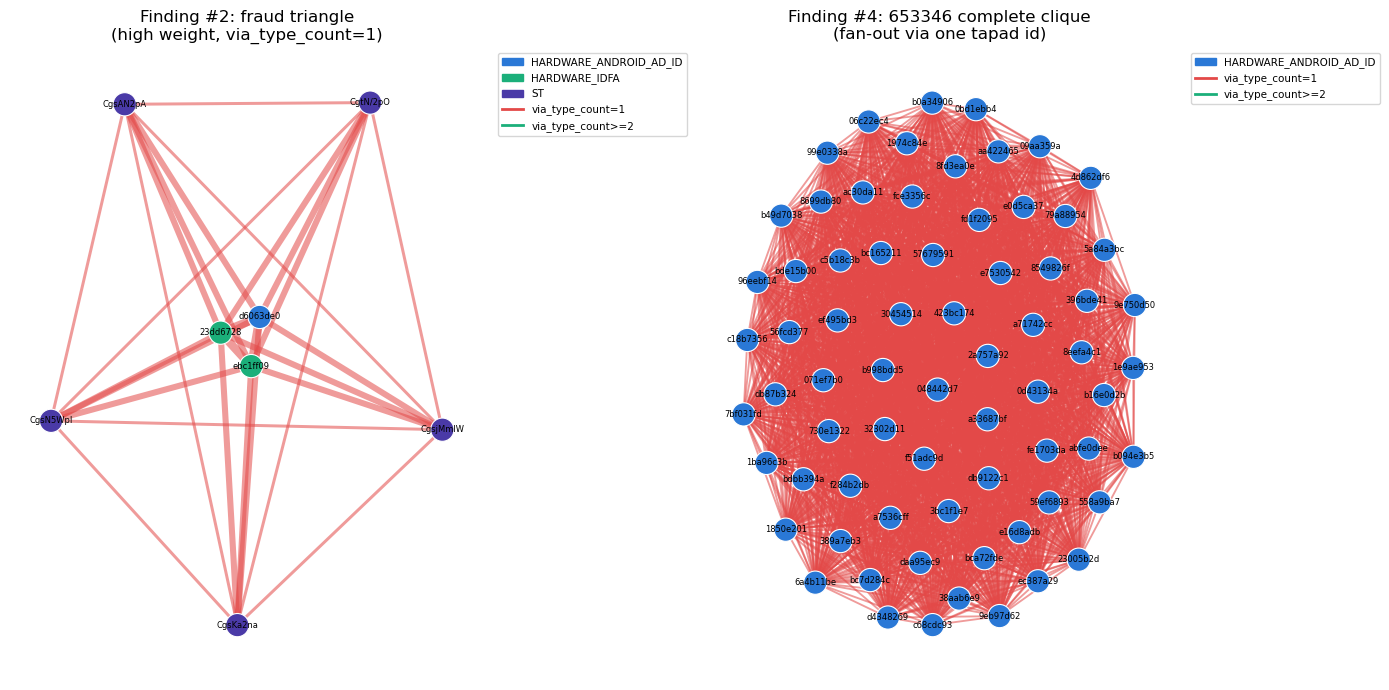

In [9]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import networkx as nx

# fixed categorical hues, same order/values used for the type x type heatmap artifact
_ALL_TYPES = sorted(node_types["type"].unique())
_PALETTE = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]
TYPE_COLORS = dict(zip(_ALL_TYPES, _PALETTE))

CONFIDENT_COLOR = "#1baf7a"   # via_type_count >= 2
SUSPECT_COLOR = "#e34948"     # via_type_count == 1


def plot_component(component_id, ax=None, seed=42, label_chars=8, title=None):
    """Generic node-link plot for any component_id. Works for a 3-node triangle or a
    much larger cluster alike -- nothing here is specific to a particular example."""
    members, edges_in = view_component(component_id)

    G = nx.Graph()
    for _, row in members.iterrows():
        G.add_node(row["node_id"], type=row["type"])
    for _, row in edges_in.iterrows():
        G.add_edge(row["node_a"], row["node_b"], weight=row["weight"], via_type_count=row["via_type_count"])

    pos = nx.spring_layout(G, seed=seed, k=1.8 / max(len(G) ** 0.5, 1))

    node_colors = [TYPE_COLORS.get(G.nodes[n]["type"], "#898781") for n in G.nodes]
    edge_colors = [SUSPECT_COLOR if G.edges[e]["via_type_count"] == 1 else CONFIDENT_COLOR for e in G.edges]
    edge_widths = [min(1 + np.log1p(G.edges[e]["weight"]) / 2, 6) for e in G.edges]

    owns_fig = ax is None
    if owns_fig:
        fig, ax = plt.subplots(figsize=(6.5, 6.5))

    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=280, edgecolors="white", linewidths=0.8, ax=ax)
    nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=edge_widths, alpha=0.55, ax=ax)
    labels = {n: n.split(":", 1)[1][:label_chars] for n in G.nodes}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=6, ax=ax)

    present_types = members["type"].unique()
    type_handles = [mpatches.Patch(color=TYPE_COLORS[t], label=t) for t in _ALL_TYPES if t in present_types]
    edge_handles = [
        mlines.Line2D([0], [0], color=SUSPECT_COLOR, lw=2, label="via_type_count=1"),
        mlines.Line2D([0], [0], color=CONFIDENT_COLOR, lw=2, label="via_type_count>=2"),
    ]
    ax.legend(handles=type_handles + edge_handles, loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=7.5)
    ax.set_title(title or f"Component {component_id}\n{len(G.nodes)} nodes, {len(G.edges)} edges")
    ax.axis("off")
    if owns_fig:
        plt.tight_layout()
        plt.show()
    return G


# side-by-side: the two fraud patterns from Findings, same generic function
top_cid = (
    result[["component", "component_size"]]
    .drop_duplicates("component")
    .nlargest(1, "component_size")["component"]
    .iloc[0]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
plot_component(triangle_cid, ax=axes[0], title="Finding #2: fraud triangle\n(high weight, via_type_count=1)")
plot_component(top_cid, ax=axes[1], title=f"Finding #4: {top_cid} complete clique\n(fan-out via one tapad id)")
plt.tight_layout()
plt.show()

## Type × type connectivity matrix

Row-normalized: each cell is the % of that **row** type's edges that go to the column type (row sums to 100%, shown as `n=` row total). A live heatmap of this exact table (with hover tooltips) is published here: https://claude.ai/code/artifact/c29bc951-3dea-453d-9c99-b1a79ae71721

In [ ]:
TYPES = sorted(node_types["type"].unique())
type_map = node_types.set_index("node_id")["type"]
edges_df["type_a"] = edges_df["node_a"].map(type_map)
edges_df["type_b"] = edges_df["node_b"].map(type_map)

# symmetric directed view: each edge counted from both endpoints' perspective
_fwd = edges_df[["type_a", "type_b", "weight", "via_type_count"]].rename(
    columns={"type_a": "row", "type_b": "col"}
)
_bwd = edges_df[["type_b", "type_a", "weight", "via_type_count"]].rename(
    columns={"type_b": "row", "type_a": "col"}
)
directed = pd.concat([_fwd, _bwd], ignore_index=True)


def type_matrix(agg="count", value_col=None):
    """count | pct | median(value_col) matrix, TYPES x TYPES, row-normalized for pct."""
    if agg == "count":
        mat = directed.groupby(["row", "col"]).size().unstack(fill_value=0)
    elif agg == "pct":
        counts = directed.groupby(["row", "col"]).size().unstack(fill_value=0)
        mat = (100 * counts.div(counts.sum(axis=1), axis=0)).round(2)
    elif agg == "median":
        mat = directed.groupby(["row", "col"])[value_col].median().unstack()
    else:
        raise ValueError(agg)
    return mat.reindex(index=TYPES, columns=TYPES)


# count_matrix is kept (not printed, raw counts are redundant with the % view below) --
# it's reused by the Multi-hop / transitive linkage section further down.
count_matrix = type_matrix("count")
pct_matrix = type_matrix("pct")
row_totals = directed.groupby("row").size().reindex(TYPES)

# avg_degree = row_total / connected_nodes -- row_total counts EDGE-ENDPOINTS (sum of
# degree), not nodes, so this converts it into a per-node average. Reuses `connected`
# from the Per-type connectivity cell above.
connected_node_counts = connected.groupby("type").size().reindex(TYPES)
avg_degree_by_type = (row_totals / connected_node_counts).round(2)

print("Row-normalized %:")
disp = pct_matrix.copy()
disp["n (row total)"] = row_totals.values
disp["avg_degree"] = avg_degree_by_type.values
print(disp.to_string())

Row-normalized %:
col                     HARDWARE_ANDROID_AD_ID  HARDWARE_IDFA  HEM_MD5  ID5_UID     ST    TTD  n (row total)  avg_degree
row                                                                                                                     
HARDWARE_ANDROID_AD_ID                   51.85          34.12     3.36     1.84   7.15   1.68         393160        2.51
HARDWARE_IDFA                            37.49          49.71     3.84     2.13   5.15   1.68         357768        2.32
HEM_MD5                                  27.93          29.04    11.32    14.06   4.87  12.79          47258        1.90
ID5_UID                                   0.05           0.06     0.05    84.57   0.01  15.26       13353309        1.23
ST                                       37.38          24.48     3.06     1.34  31.84   1.90          75232        2.73
TTD                                       0.23           0.21     0.21    72.41   0.05  26.88        2814767        1.39


### Type × type × via_type breakdown

The matrix above shows *how many* edges connect two types, but not *which* grouping key (`id5` / `tapad` / `liid`) produced them. That turns out to matter a lot: the three via_types aren't interchangeable, they each dominate a different slice of the graph. `id5` only ever appears in edges touching `ID5_UID`/`TTD` (consistent with Finding #4's fan-out audit, which never saw `id5` as an outlier there -- but that was specifically about the >=10-node fan-out check; `id5` is very much present and dominant for ordinary `ID5_UID`<->`ID5_UID`/`ID5_UID`<->`TTD` linkage, as this breakdown shows). `liid` dominates the hardware-ID/`ST` cluster. `tapad` is a thin minority contributor almost everywhere -- except `HEM_MD5`<->`HEM_MD5`, where it's the *only* source.

In [ ]:
def via_type_breakdown():
    """Direct-edge counts broken down by type pair AND which grouping-key type
    produced them (id5 / tapad / liid) -- not just how many edges exist between two
    types, but which underlying join key is responsible. Reveals the graph is really
    3 loosely-overlapping subgraphs: id5 dominates ID5_UID/TTD linkage, liid dominates
    the hardware-ID/ST cluster, tapad is a thin minority almost everywhere except
    HEM_MD5<->HEM_MD5 (100% tapad)."""
    parts = []
    for vt in ["id5", "tapad", "liid"]:
        con = duckdb.connect()
        con.execute("SET preserve_insertion_order=false")
        vk = via_keys[via_keys["via_type"] == vt][["node_id", "via_key"]]
        con.register("vk", vk)
        pairs = con.execute("""
            SELECT a.node_id AS node_a, b.node_id AS node_b
            FROM vk a JOIN vk b ON a.via_key = b.via_key AND a.node_id < b.node_id
        """).df()
        pairs["via_type"] = vt
        parts.append(pairs)

    all_pairs = pd.concat(parts, ignore_index=True)
    all_pairs["type_a"] = all_pairs["node_a"].str.split(":", n=1).str[0]
    all_pairs["type_b"] = all_pairs["node_b"].str.split(":", n=1).str[0]

    fwd = all_pairs[["type_a", "type_b", "via_type"]].rename(columns={"type_a": "row", "type_b": "col"})
    bwd = all_pairs[["type_b", "type_a", "via_type"]].rename(columns={"type_b": "row", "type_a": "col"})
    directed_vt = pd.concat([fwd, bwd], ignore_index=True)

    breakdown = directed_vt.groupby(["row", "col", "via_type"]).size().unstack("via_type", fill_value=0)
    breakdown["total"] = breakdown.sum(axis=1)
    return breakdown.sort_values(["row", "total"], ascending=[True, False])


type_via_breakdown = via_type_breakdown()

# row-normalized: % of each (row,col) pair's edges attributable to each via_type,
# with the raw total kept alongside for scale
via_type_cols = [c for c in type_via_breakdown.columns if c != "total"]
type_via_pct = (100 * type_via_breakdown[via_type_cols].div(type_via_breakdown["total"], axis=0)).round(2)
type_via_pct["total"] = type_via_breakdown["total"]
print(type_via_pct.to_string())

via_type                                         id5   liid   tapad     total
row                    col                                                   
HARDWARE_ANDROID_AD_ID HARDWARE_ANDROID_AD_ID   0.00  99.82    0.18  13676584
                       HARDWARE_IDFA            0.00  99.93    0.07   6172979
                       HEM_MD5                  0.00  99.11    0.89    533142
                       ST                       0.00  99.90    0.10    488810
                       TTD                      0.00  58.76   41.24     15976
                       ID5_UID                  0.00   0.00  100.00      7331
HARDWARE_IDFA          HARDWARE_ANDROID_AD_ID   0.00  99.93    0.07   6172979
                       HARDWARE_IDFA            0.00  99.76    0.24   4927174
                       ST                       0.00  99.90    0.10    275358
                       HEM_MD5                  0.00  98.00    2.00    229031
                       TTD                      0.00  37.99   62

### Node-level via_type membership: bridge nodes

The breakdown above is edge-level: for a given *pair* of nodes, how many via_types corroborate that specific link. This is a different question -- does a single *node* (by value) show up across multiple source datasets at all, possibly linking to completely different neighbors through each one? E.g. a `HEM_MD5` hash seen in both a `tapad`-sourced row and a `liid`-sourced row can bridge an `ID5_UID` (reached via `tapad`) to a `HARDWARE_IDFA` (reached via `liid`) that would otherwise never be connected -- the two source datasets never overlap except through this one value. Aggregated by `type` (only 6 values, same cardinality as everything else here) rather than by individual node.

In [ ]:
def node_via_type_membership():
    """For every node, which via_types (source datasets: id5/tapad/liid) does it
    appear under at all -- regardless of which other node it links to through each.
    Different from edge-level via_type_count: a node can show up in two datasets
    while linking to two COMPLETELY DIFFERENT neighbors through each one."""
    node_via_types = via_keys.groupby("node_id")["via_type"].apply(lambda s: frozenset(s.unique()))
    df = node_via_types.reset_index(name="via_types")
    df["type"] = df["node_id"].str.split(":", n=1).str[0]
    df["n_via_types"] = df["via_types"].apply(len)
    return df


node_via = node_via_type_membership()

print("Per-type: how many nodes appear in 1 vs 2 vs 3 distinct source datasets?")
print(node_via.groupby(["type", "n_via_types"]).size().unstack(fill_value=0).to_string())

print("\nExact via_type combinations, per type:")
print(node_via.groupby(["type", "via_types"]).size().sort_values(ascending=False).to_string())

Bridge example: HEM_MD5:04db8818a7c319c88e1f60102cabe139
  via tapad -> ['HARDWARE_ANDROID_AD_ID:ed34095b-21b9-4b8e-88b4-1ee26bec33d5', 'TTD:246abb0a-b285-403c-8b3b-b17bb4ed885d', 'HEM_MD5:fc262b0dd8ef92a872eb8e414e38ad79', 'HEM_MD5:644592ebf349b2529787ef70af26e5b6', 'ID5_UID:ID5-bb43ibhU90xNppN64kkY24dPIVYF5f1Bx71Ojmyaxw']
  via liid -> ['HARDWARE_ANDROID_AD_ID:75cd511c-5ca8-4db7-a017-e8b6cd3d0d9e', 'HARDWARE_IDFA:9b651c2b-f61a-4c6d-8e8c-6dfe6cd1f245']


In [ ]:
# concrete example: a value bridging two otherwise-unrelated identifiers through
# two different source datasets
bridge_candidates = node_via[(node_via["type"] == "HEM_MD5") & (node_via["n_via_types"] >= 2)]
bridge_example = bridge_candidates["node_id"].iloc[0]

print(f"Bridge example: {bridge_example}")
rows = via_keys[via_keys["node_id"] == bridge_example].drop_duplicates(["via_type", "via_key"])
for _, r in rows.iterrows():
    neighbors = via_keys.loc[
        (via_keys["via_type"] == r["via_type"])
        & (via_keys["via_key"] == r["via_key"])
        & (via_keys["node_id"] != bridge_example),
        "node_id",
    ].unique()
    print(f"  via {r['via_type']} -> {list(neighbors)}")

## Weight distribution

`weight` = number of distinct grouping keys (id5/tapad/liid values) that produced a given edge. Low end is exact counts; the tail is bucketed since a handful of edges reach into the tens of thousands (see Findings).

In [11]:
FIXED_BINS = [10, 20, 50, 100, 1000, 10_000, 100_000]


def overall_histogram(col, low_max=10):
    low = edges_df[edges_df[col] <= low_max][col].value_counts().sort_index()
    hist = low.rename(lambda x: str(x))

    tail_vals = edges_df[edges_df[col] > low_max][col]
    if len(tail_vals):
        edges = [b for b in FIXED_BINS if b > low_max]
        if not edges or edges[-1] < tail_vals.max():
            edges.append(int(tail_vals.max()) + 1)
        bins = [low_max] + edges
        labels = [f"{bins[i]+1}-{bins[i+1]}" for i in range(len(bins) - 1)]
        tail = pd.cut(tail_vals, bins=bins, labels=labels).value_counts().sort_index()
        tail = tail[tail > 0]
        hist = pd.concat([hist, tail])

    pct = (100 * hist / len(edges_df)).round(2)
    return pd.DataFrame({"edge_count": hist, "pct": pct})


def per_type_histogram(col, low_max=10):
    for t in TYPES:
        sub = directed[directed["row"] == t][col]
        print(f"--- {t} (n={len(sub):,}, median={sub.median():.0f}, mean={sub.mean():.2f}) ---")
        low = sub[sub <= low_max].value_counts().sort_index()
        n_tail = (sub > low_max).sum()
        print(low.rename(lambda x: str(x)).to_string())
        if n_tail:
            print(f">{low_max}   {n_tail}")


print("=== OVERALL weight histogram ===")
print(overall_histogram("weight").to_string())
print("\n=== PER-TYPE weight histogram (edges touching that type) ===")
per_type_histogram("weight")

=== OVERALL weight histogram ===


              edge_count    pct
weight                         
1                8340860  97.89
2                   4096   0.05
3                   3120   0.04
4                  36423   0.43
5                   2698   0.03
6                   2380   0.03
7                   2305   0.03
8                   2151   0.03
9                  22632   0.27
10                  1955   0.02
11-20              26121   0.31
21-50              35114   0.41
51-100             15473   0.18
101-1000           23149   0.27
1001-10000          2169   0.03
10001-100000         101   0.00

=== PER-TYPE weight histogram (edges touching that type) ===
--- HARDWARE_ANDROID_AD_ID (n=393,160, median=1, mean=53.15) ---
weight
1     221229
2       1695
3       1475
4      34353
5       1449
6       1246
7       1280
8       1228
9      22075
10      1141
>10   105989


--- HARDWARE_IDFA (n=357,768, median=1, mean=32.48) ---
weight
1     224613
2       1766
3       1532
4      33074
5       1186
6       1052
7        943
8        847
9      20486
10       773
>10   71496


--- HEM_MD5 (n=47,258, median=1, mean=17.09) ---
weight
1     39524
2       133
3       123
4      1705
5        98
6        80
7        83
8        79
9       987
10       58
>10   4388


--- ID5_UID (n=13,353,309, median=1, mean=1.00) ---
weight
1    13352427
2         859
3           5
5           4
6           2
7           1
>10   11


--- ST (n=75,232, median=4, mean=10.91) ---
weight
1     29726
2      3366
3      3102
4      3679
5      2656
6      2377
7      2297
8      2142
9      1703
10     1938
>10   22246


--- TTD (n=2,814,767, median=1, mean=1.01) ---
weight
1    2814201
2        373
3          3
4         35
5          3
6          3
7          6
8          6
9         13
>10   124


In [12]:
print("Type x type MEDIAN weight matrix:")
print(type_matrix("median", "weight").to_string())

Type x type MEDIAN weight matrix:


col                     HARDWARE_ANDROID_AD_ID  HARDWARE_IDFA  HEM_MD5  ID5_UID    ST  TTD
row                                                                                       
HARDWARE_ANDROID_AD_ID                     1.0            1.0      1.0      1.0  11.0  1.0
HARDWARE_IDFA                              1.0            1.0      1.0      1.0   7.0  1.0
HEM_MD5                                    1.0            1.0      1.0      1.0   6.0  1.0
ID5_UID                                    1.0            1.0      1.0      1.0   1.0  1.0
ST                                        11.0            7.0      6.0      1.0   1.0  1.0
TTD                                        1.0            1.0      1.0      1.0   1.0  1.0


## `via_type_count` distribution

`via_type_count` = number of *independent* grouping-key types (id5, tapad, liid — max 3) that corroborate a link, regardless of how many times each. This is the better confidence signal: a pair linked once via id5 **and** once via tapad (via_type_count=2, weight=2) is stronger evidence than a pair linked 1000 times purely through id5 (via_type_count=1, weight=1000) — see Findings.

In [13]:
print("=== OVERALL via_type_count histogram ===")
print(overall_histogram("via_type_count", low_max=3).to_string())
print("\n=== PER-TYPE via_type_count histogram (edges touching that type) ===")
per_type_histogram("via_type_count", low_max=3)
print("\nType x type MEDIAN via_type_count matrix:")
print(type_matrix("median", "via_type_count").to_string())

=== OVERALL via_type_count histogram ===


                edge_count    pct
via_type_count                   
1                  8520134  99.99
2                      613   0.01

=== PER-TYPE via_type_count histogram (edges touching that type) ===
--- HARDWARE_ANDROID_AD_ID (n=393,160, median=1, mean=1.00) ---
via_type_count
1    393159
2         1


--- HARDWARE_IDFA (n=357,768, median=1, mean=1.00) ---
via_type_count
1    357768


--- HEM_MD5 (n=47,258, median=1, mean=1.00) ---
via_type_count
1    47257
2        1


--- ID5_UID (n=13,353,309, median=1, mean=1.00) ---
via_type_count
1    13352454
2         855


--- ST (n=75,232, median=1, mean=1.00) ---
via_type_count
1    75232


--- TTD (n=2,814,767, median=1, mean=1.00) ---
via_type_count
1    2814398
2        369

Type x type MEDIAN via_type_count matrix:


col                     HARDWARE_ANDROID_AD_ID  HARDWARE_IDFA  HEM_MD5  ID5_UID   ST  TTD
row                                                                                      
HARDWARE_ANDROID_AD_ID                     1.0            1.0      1.0      1.0  1.0  1.0
HARDWARE_IDFA                              1.0            1.0      1.0      1.0  1.0  1.0
HEM_MD5                                    1.0            1.0      1.0      1.0  1.0  1.0
ID5_UID                                    1.0            1.0      1.0      1.0  1.0  1.0
ST                                         1.0            1.0      1.0      1.0  1.0  1.0
TTD                                        1.0            1.0      1.0      1.0  1.0  1.0


## High-confidence filter: `via_type_count >= n1` AND `weight >= n2`

Filtering **before** running connected_components (not after) matters: once components are computed, a weak edge has already merged whatever it bridged — filtering afterward can't undo that. `N1_VIA_TYPE_COUNT`/`N2_WEIGHT` are set in the config cell at the top; tune and re-run.

In [14]:
def compare_confidence_levels(levels):
    """levels: list of (label, n1_via_type_count, n2_weight) -> comparison table.
    Uses run_cc(return_full=False) -- no pandas groupby/join at node scale, just the
    shared NODE_INDEX + a vectorized bincount, so this is now fast for any number of
    levels."""
    rows = []
    for label, n1, n2 in levels:
        filt = edges_df[(edges_df["via_type_count"] >= n1) & (edges_df["weight"] >= n2)]
        sizes, n_comp = run_cc(filt, return_full=False)
        rows.append(
            {
                "level": label,
                "n1_via_type_count": n1,
                "n2_weight": n2,
                "edges_kept": len(filt),
                "pct_edges_kept": round(100 * len(filt) / len(edges_df), 2),
                "n_components": n_comp,
                "n_singleton_components": int((sizes == 1).sum()),
                "largest_component": int(sizes.max()),
            }
        )
    return pd.DataFrame(rows)


comparison = compare_confidence_levels(
    [
        ("loose (all edges)", 1, 1),
        (f"strict (via_type_count>={N1_VIA_TYPE_COUNT})", N1_VIA_TYPE_COUNT, 1),
        (f"strict (weight>={N2_WEIGHT})", 1, N2_WEIGHT),
        (f"strict (both, n1={N1_VIA_TYPE_COUNT}, n2={N2_WEIGHT})", N1_VIA_TYPE_COUNT, N2_WEIGHT),
    ]
)
comparison

,level,n1_via_type_count,n2_weight,edges_kept,pct_edges_kept,n_components,n_singleton_components,largest_component
0,loose (all edges),1,1,8520747,100.00,52393107,46330745,70
1,strict (via_type_count>=2),2,1,613,0.01,59547740,59547172,4
2,strict (weight>=2),1,2,179887,2.11,59455472,59413862,23
3,"strict (both, n1=2, n2=2)",2,2,613,0.01,59547740,59547172,4


## Multi-hop / transitive linkage

`connected_components` already discovers "ST linked to HEM_MD5 *via* a shared TTD" automatically — component membership is reachability, not direct adjacency, so it's depth-unlimited by construction. What it does *not* do is tell you which same-component pairs only exist because of a chain, vs. a direct edge. This computes that explicitly: for every component (size ≥ 2), count every same-component node-pair by type, then subtract the direct-edge type matrix — the remainder is "connected, but only transitively."

In [15]:
# component x type count matrix, restricted to non-singleton components (singletons can't have pairs)
multi = result[result["component_size"] > 1]
comp_type_counts = multi.groupby(["component", "type"]).size().unstack(fill_value=0).reindex(columns=TYPES, fill_value=0)
print(f"{len(comp_type_counts):,} non-singleton components covering {multi.shape[0]:,} nodes")

# ordered same-component node-pair matrix: M[i,j] = sum over components of a_i * a_j (i!=j),
# diagonal adjusted from a_i^2 to a_i*(a_i-1) since a node can't pair with itself
A = comp_type_counts[TYPES].to_numpy(dtype=np.int64)
M = A.T @ A
type_totals = A.sum(axis=0)
np.fill_diagonal(M, np.diag(M) - type_totals)
total_pairs_matrix = pd.DataFrame(M, index=TYPES, columns=TYPES)

indirect_only_matrix = total_pairs_matrix - count_matrix.reindex(index=TYPES, columns=TYPES).fillna(0)

print("\nSame-component pairs WITH NO direct edge (indirect-only linkage), by type pair:")
print(indirect_only_matrix.astype(np.int64).to_string())

print("\n...as a % of all same-component pairs for that type pair:")
pct_indirect = (100 * indirect_only_matrix / total_pairs_matrix.replace(0, np.nan)).round(1)
print(pct_indirect.to_string())

6,062,362 non-singleton components covering 13,217,585 nodes

Same-component pairs WITH NO direct edge (indirect-only linkage), by type pair:
                        HARDWARE_ANDROID_AD_ID  HARDWARE_IDFA  HEM_MD5  ID5_UID    ST   TTD
HARDWARE_ANDROID_AD_ID                    9244           8288      484      534  1496   191
HARDWARE_IDFA                             8288           8650      493      493  1343   156
HEM_MD5                                    484            493       36      496    86   133
ID5_UID                                    534            493      496     2114   149  1628
ST                                        1496           1343       86      149   404    58
TTD                                        191            156      133     1628    58   904

...as a % of all same-component pairs for that type pair:
                        HARDWARE_ANDROID_AD_ID  HARDWARE_IDFA  HEM_MD5  ID5_UID    ST  TTD
HARDWARE_ANDROID_AD_ID                     4.3            5.8   

## Findings

In [16]:
# The highest-weight edges with the *weakest* corroboration (via_type_count==1) are
# the prime suspects for spurious/sentinel/fraud-farm links, not genuine identity links.
suspect = edges_df[edges_df["via_type_count"] == 1].sort_values("weight", ascending=False).head(15)
print("Top weight, single-grouping-type-corroborated edges (suspect):")
print(suspect[["node_a", "node_b", "weight", "via_type_count"]].to_string(index=False))

Top weight, single-grouping-type-corroborated edges (suspect):
                                                     node_a                                                      node_b  weight  via_type_count
HARDWARE_ANDROID_AD_ID:d6063de0-b218-43c4-a768-ba23f939652c          HARDWARE_IDFA:23dd6728-bfc4-42dc-a50f-337f7e73799b   81225               1
HARDWARE_ANDROID_AD_ID:d6063de0-b218-43c4-a768-ba23f939652c          HARDWARE_IDFA:ebc1ff09-38d3-4349-83b4-4aa6b5b12c7b   81225               1
         HARDWARE_IDFA:23dd6728-bfc4-42dc-a50f-337f7e73799b          HARDWARE_IDFA:ebc1ff09-38d3-4349-83b4-4aa6b5b12c7b   81225               1
HARDWARE_ANDROID_AD_ID:2a8f69fb-69b0-43a6-b8cf-83146c107376 HARDWARE_ANDROID_AD_ID:2d5a0ce1-f7a3-4513-a0e9-16eb89565d79   71824               1
HARDWARE_ANDROID_AD_ID:897bac26-b625-4637-ac70-8ffbd4e465e0          HARDWARE_IDFA:8ec02ce7-5529-4a71-af5e-86909f7ba76d   55696               1
HARDWARE_ANDROID_AD_ID:09e95751-b496-49d5-a577-058c6d352c7a          HARD

In [17]:
import base64

# What actually IS an `ST` value? Every one is a fixed-length base64 string ending in
# "==" -- that's not a data quality issue, it's a deterministic consequence of a fixed
# byte length (any N-byte blob with N % 3 == 1 base64-encodes to "==" padding).
st_values = node_types.loc[node_types["type"] == "ST", "node_id"].str.split(":", n=1).str[1]
print("ST value lengths:", st_values.str.len().value_counts().to_dict())
print("pct ending in '==':", (st_values.str.endswith("==")).mean())

for v in st_values.head(3):
    raw = base64.b64decode(v)
    print(f"{v} -> {len(raw)} bytes, hex={raw.hex()}")

ST value lengths: {24: 37313}
pct ending in '==': 1.0
CgsA3mo/KPQAAAAJCFEYAw== -> 16 bytes, hex=0a0b00de6a3f28f40000000908511803
CgsAGmlBtJIAAAAJIpZSAw== -> 16 bytes, hex=0a0b001a6941b4920000000922965203
CgsAGmmctLEAAAAJP3A7Aw== -> 16 bytes, hex=0a0b001a699cb4b1000000093f703b03


### 1. `ST` isn't a US state -- it's a fixed-schema, protobuf-serialized token

`ST` is the only type whose median edge weight is >1 (4 overall; 6–11 specifically when paired with hardware IDs), and it's the only type whose count-matrix diagonal (`ST`↔`ST`) is a meaningfully large share of its own edges. Every other type has median weight 1 across the board.

Decoding what `ST` values actually are (above) explains the shape, not just the linkage: every value is exactly 24 base64 characters -> exactly 16 raw bytes, and the first two bytes are always `0a 0b` (hex) -- a protobuf field tag + length prefix (field 1, length-delimited, an 11-byte sub-message). So `ST` is a **fixed-schema serialized token** (state/session data), not a geographic code -- only the payload bytes vary between records, the structure is constant. (Side note, not a bug: every `ST` value ends in `==` -- that's just base64 padding, mathematically guaranteed for any fixed 16-byte blob, since 16 % 3 == 1 always yields 2 padding chars. Also: `plot_component()`'s on-screen labels are truncated to `label_chars=8` for readability, which is why the visualized labels don't show the `==` -- the full untruncated values are still in `members`/`edges_in`.)

**Update, see Finding #2 below:** at least part of `ST`'s odd linkage behavior is explained by it being entangled in the same fraud cluster as the hardware-ID clique, not a separate phenomenon.

### 2. Fully-connected 8-node clique — probable fraud/emulator/sentinel signature, not real links

The component containing the original 3-node "triangle" turned out to be larger once actually visualized (below): **8 nodes, 28 internal edges = exactly C(8,2), a complete clique** — 3 hardware IDs (1 `HARDWARE_ANDROID_AD_ID`, 2 `HARDWARE_IDFA`) *and* 5 `ST` values, every one directly linked to every other. Edge weights range from 9 to **81,225** (mean ~9,164) — meaning up to ~81K distinct grouping-key values (e.g. `individual_id5`s) all reported having the *same* handful of exact device/ST identifiers attached. Real devices don't do this — an iOS device can't hold two different IDFAs, and unrelated people can't legitimately share one Android ad ID or the same handful of `ST` values.

Critically: **`via_type_count == 1` on all 28 edges** — every unit of evidence came from repetition through a **single** grouping-key type (e.g. all via `individual_id5`), never independently corroborated via `individual_id_tapad` or `liid`. That's why `via_type_count` is the better filter than raw `weight`: a pair linked once each via id5, tapad, *and* liid (via_type_count=3, weight=3) is far more trustworthy than a pair linked 81,225 times purely through id5 (via_type_count=1). The `suspect` table above is exactly this filter (`via_type_count==1`, sorted by weight) — re-run it after switching to the full dataset (`SAMPLE=False`) to get the real denylist candidates; the mitigation is a **value-level denylist** of specific `(type, value)` nodes (not a whole-type exclusion like we used for `ip` earlier), since most IDFA/AAID/ST values are perfectly fine and only a handful of specific values are pathological.

### 3. Transitive closure is already unlimited-depth — and that's also the risk

`connected_components` computes reachability, not adjacency — so "is `ST` linked to `HEM_MD5` via a shared `TTD`" is automatically discovered with zero extra code; any path of any length merges nodes into one component. The **Multi-hop / transitive linkage** section above quantifies this directly: for every type pair, how many same-component node-pairs exist *only* transitively (no direct edge) vs. directly.

The catch: this transitivity is depth-blind **and confidence-blind**. A single `weight=1, via_type_count=1` edge — the least trustworthy kind — can act as a bridge that silently merges two otherwise-unrelated components into one giant one, and once that merge happens, nothing in the component output tells you it happened via one fragile link vs. many strong ones. This is why the **filter-before-CC** section above matters: filtering weak edges out *before* computing components prevents these low-confidence bridges from forming in the first place; filtering *after* can't undo an already-merged identity. If bridge risk needs to be audited more precisely later (which specific edge, if removed, would split a component), that's a graph "bridge/articulation-edge" analysis — feasible per-component here since components are small (largest in the sample is 70 nodes) — worth adding if the strict-vs-loose comparison above shows components collapsing a lot under the loose filter.

### 4. The single largest component is *also* a fraud signature — from the opposite direction

The 70-node component (the largest in the sample) is *also* a complete clique — 2,415 internal edges = exactly C(70,2), every one of 70 `HARDWARE_ANDROID_AD_ID` nodes directly linked to every other. Unlike Finding #2 (a few *(type,value)* pairs repeated across many grouping keys), every edge here has `weight=1, via_type_count=1` — the opposite pattern: many distinct node values tied together via a **single** grouping key. Root cause (found by checking fan-out per grouping key directly, visible in the fan-out audit above): one `individual_id_tapad` value has 70 distinct `HARDWARE_ANDROID_AD_ID`s attached to it — almost certainly a shared/proxy device or bot-farm session, not one real device holding 70 Android ad IDs. The fan-out audit above shows this is systemic, not a one-off: every outlier grouping key (≥10 distinct nodes tied together) is `tapad` or `liid` — **never `id5`** — suggesting the fraud pattern specifically enters through the tapad/liid side of the join, not the id5 side.

**Practical implication:** the two fraud patterns need two different detectors, both demonstrated above. Finding #2's detector (`via_type_count==1`, sort by `weight` descending) catches high-*repetition* pairs. Finding #4's detector is the opposite — **fan-out per grouping key** (`COUNT(DISTINCT node_id) GROUP BY individual_id5/individual_id_tapad/liid`, flagging outliers), which is exactly the diagnostic that was cut short earlier in this session by the disk-filling incident, now added as a standing check above. Both example components are visualized side-by-side above using the generic `plot_component()` — worth running on any suspiciously large or fully-connected component before trusting it.